In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfTransformer
from sklearn.metrics.pairwise import cosine_similarity
import warnings

warnings.filterwarnings('ignore')

# macOS 및 Windows 한글 폰트 설정
plt.rc('font', family='AppleGothic') # Windows의 경우 'Malgun Gothic'으로 변경
plt.rcParams['axes.unicode_minus'] = False

# 1. 데이터 로드 및 전처리
df = pd.read_csv('dummy_data.csv')
df_clean = df.dropna(subset=['언급된 브랜드']).copy()
df_clean['브랜드_리스트'] = df_clean['언급된 브랜드'].apply(lambda x: [brand.strip() for brand in x.split(',')])
df_exploded = df_clean.explode('브랜드_리스트').rename(columns={'브랜드_리스트': '브랜드'})

# =========================================================
# [분석 타겟 설정] 분석하고 싶은 특정 브랜드를 입력하세요.
# =========================================================
TARGET_BRAND = '이안과' # 예시로 BGN밝은눈안과 설정

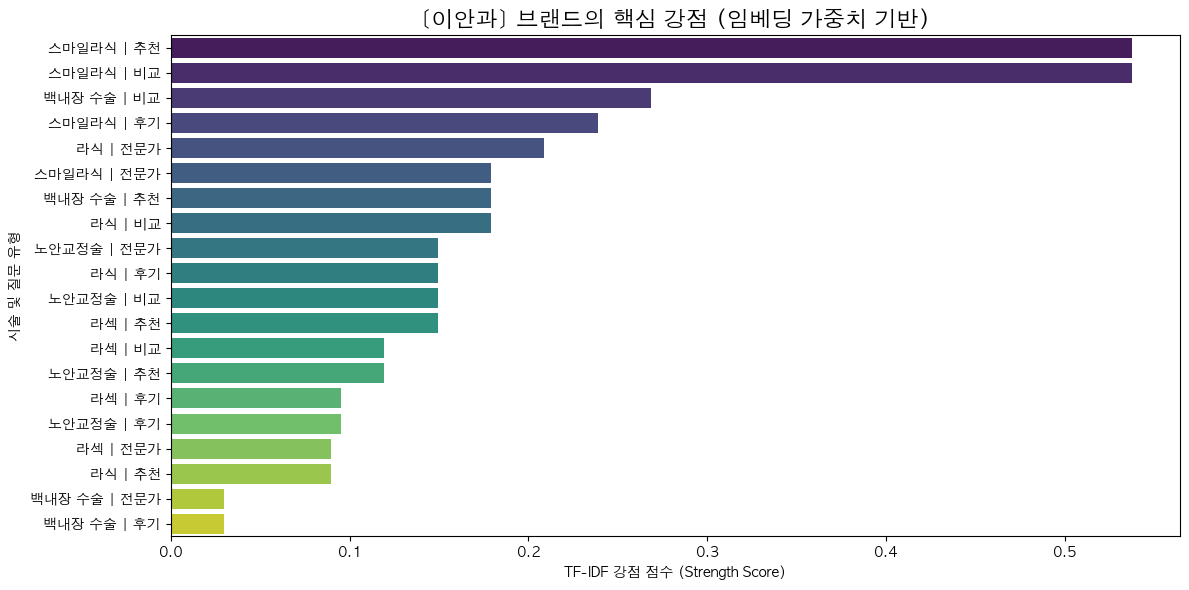

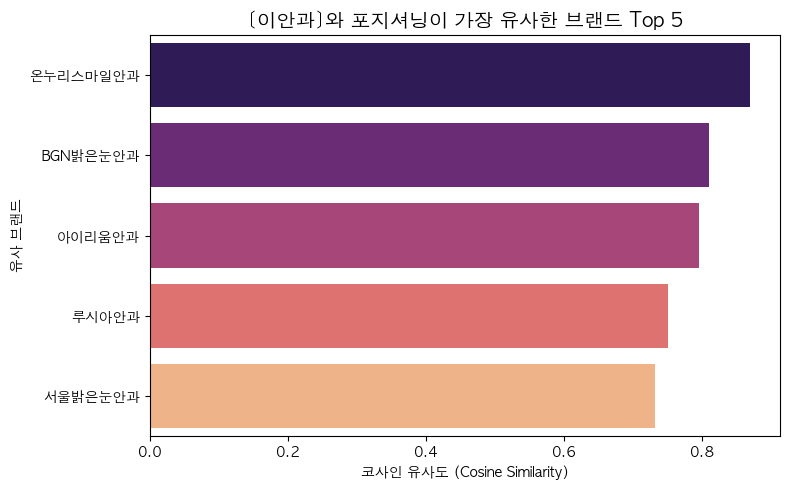

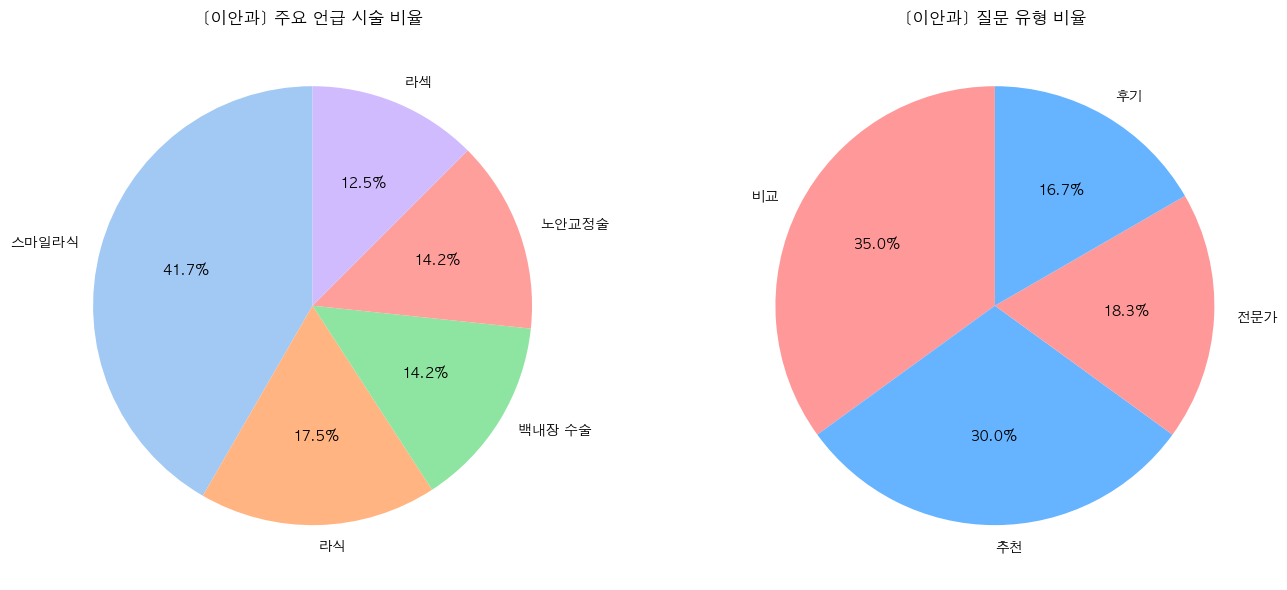

In [4]:
# ---------------------------------------------------------
# 2. 브랜드 임베딩 (Feature Vector 구축)
# ---------------------------------------------------------
# 시술(procedure), 유형, 속성(attribute)을 결합하여 브랜드가 가진 고유의 '맥락 특성' 생성
df_exploded['context_feature'] = df_exploded['procedure'] + " | " + df_exploded['유형']

# 브랜드(Row) x 맥락 특성(Column) 빈도 행렬 생성
pivot_df = pd.crosstab(df_exploded['브랜드'], df_exploded['context_feature'])

# TF-IDF 변환: 단순히 많이 언급된 특성보다, 해당 브랜드에 유독 집중된 '강점'에 높은 가중치 부여
tfidf = TfidfTransformer()
brand_embeddings = tfidf.fit_transform(pivot_df).toarray()
embedding_df = pd.DataFrame(brand_embeddings, index=pivot_df.index, columns=pivot_df.columns)

if TARGET_BRAND not in embedding_df.index:
    print(f"데이터에 '{TARGET_BRAND}' 브랜드가 존재하지 않습니다.")
else:
    # ---------------------------------------------------------
    # 3. 특정 브랜드 집중 분석: 어떤 시술/유형에 강한가?
    # ---------------------------------------------------------
    # 타겟 브랜드의 특성 임베딩 벡터 추출 및 정렬
    target_vector = embedding_df.loc[TARGET_BRAND]
    top_features = target_vector[target_vector > 0].sort_values(ascending=False)
    
    plt.figure(figsize=(12, 6))
    sns.barplot(x=top_features.values, y=top_features.index, palette='viridis')
    plt.title(f'[{TARGET_BRAND}] 브랜드의 핵심 강점 (임베딩 가중치 기반)', fontsize=16)
    plt.xlabel('TF-IDF 강점 점수 (Strength Score)')
    plt.ylabel('시술 및 질문 유형')
    plt.tight_layout()
    plt.show()

    # ---------------------------------------------------------
    # 4. 임베딩 기반: 해당 브랜드와 가장 경쟁/유사한 브랜드 찾기
    # ---------------------------------------------------------
    # 코사인 유사도(Cosine Similarity)를 통해 벡터 공간상에서 가장 가까운 브랜드 탐색
    similarity_matrix = cosine_similarity(embedding_df)
    similarity_df = pd.DataFrame(similarity_matrix, index=embedding_df.index, columns=embedding_df.index)
    
    # 자기 자신을 제외한 유사도 상위 5개 브랜드
    top_similar_brands = similarity_df[TARGET_BRAND].drop(TARGET_BRAND).sort_values(ascending=False).head(5)
    
    plt.figure(figsize=(8, 5))
    sns.barplot(x=top_similar_brands.values, y=top_similar_brands.index, palette='magma')
    plt.title(f'[{TARGET_BRAND}]와 포지셔닝이 가장 유사한 브랜드 Top 5', fontsize=14)
    plt.xlabel('코사인 유사도 (Cosine Similarity)')
    plt.ylabel('유사 브랜드')
    plt.tight_layout()
    plt.show()

    # ---------------------------------------------------------
    # 5. 세부 비율 확인: 질문 유형(추천 vs 비교) 점유율 시각화 (Pie Chart)
    # ---------------------------------------------------------
    target_data = df_exploded[df_exploded['브랜드'] == TARGET_BRAND]
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # 1) 어떤 시술에서 많이 언급되는가?
    procedure_counts = target_data['procedure'].value_counts()
    axes[0].pie(procedure_counts, labels=procedure_counts.index, autopct='%1.1f%%', startangle=90, colors=sns.color_palette("pastel"))
    axes[0].set_title(f'[{TARGET_BRAND}] 주요 언급 시술 비율')
    
    # 2) 어떤 유형(추천/비교)에서 많이 언급되는가?
    type_counts = target_data['유형'].value_counts()
    axes[1].pie(type_counts, labels=type_counts.index, autopct='%1.1f%%', startangle=90, colors=['#ff9999','#66b3ff'])
    axes[1].set_title(f'[{TARGET_BRAND}] 질문 유형 비율')
    
    plt.tight_layout()
    plt.show()